In [3]:
import pandas as pd
import xml.etree.ElementTree as ET

def parse_apple_health_body_data(file_path):
    # Wczytywanie i parsowanie pliku XML
    print("Ładowanie danych... to może chwilę potrwać przy dużym eksporcie.")
    tree = ET.parse(file_path)
    root = tree.getroot()

    # Definiujemy typy danych, które nas interesują
    target_types = {
        'HKQuantityTypeIdentifierBodyMass': 'Weight_kg',
        'HKQuantityTypeIdentifierBodyMassIndex': 'BMI',
        'HKQuantityTypeIdentifierBodyFatPercentage': 'BodyFat_percent'
    }

    records = []

    for record in root.findall('Record'):
        record_type = record.get('type')
        if record_type in target_types:
            records.append({
                'Date': record.get('startDate'),
                'Metric': target_types[record_type],
                'Value': float(record.get('value'))
            })

    # Tworzenie DataFrame
    df = pd.DataFrame(records)

    # Konwersja daty i sortowanie
    df['Date'] = pd.to_datetime(df['Date'])

    # Przekształcenie tabeli, aby metryki były w kolumnach (Pivot)
    df_pivot = df.pivot_table(index='Date', columns='Metric', values='Value').sort_index()

    # Opcjonalnie: Apple podaje procent tłuszczu jako ułamek (np. 0.18 dla 18%)
    if 'BodyFat_percent' in df_pivot.columns:
        # Sprawdzamy, czy wartości wymagają przemnożenia przez 100
        if df_pivot['BodyFat_percent'].max() < 1:
            df_pivot['BodyFat_percent'] *= 100

    return df_pivot

# Użycie:
data = parse_apple_health_body_data('data/apple_health_export/export.xml')
print(data.tail())

Ładowanie danych... to może chwilę potrwać przy dużym eksporcie.
Metric                      BMI  BodyFat_percent  Weight_kg
Date                                                       
2026-03-11 11:44:49+01:00  21.5             10.5       73.9
2026-03-12 08:59:04+01:00  21.9             11.4       75.2
2026-03-13 12:42:52+01:00  21.7             11.0       74.5
2026-03-15 08:59:18+01:00  21.7             11.0       74.6
2026-03-16 08:37:42+01:00  21.6             10.7       74.1


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Zakładając, że Twoje dane są w zmiennej 'df_pivot'
# 1. Dodawanie nowego pomiaru (przykład dla dzisiejszej daty)
new_entry = pd.DataFrame({
    'BMI': [21.5],
    'BodyFat_percent': [10.6],
    'Weight_kg': [73.8]
}, index=[pd.to_datetime('2026-03-19 09:00:00+01:00')])

# Połączenie starych danych z nowymi
data = pd.concat([df_pivot, new_entry]).sort_index()

# 2. Tworzenie wykresów
sns.set_theme(style="whitegrid") # Ładniejszy styl wykresów
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

metrics = ['Weight_kg', 'BMI', 'BodyFat_percent']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
labels = ['Waga (kg)', 'BMI', 'Tłuszcz (%)']

for i, metric in enumerate(metrics):
    axes[i].plot(data.index, data[metric], marker='o', linestyle='-', color=colors[i], linewidth=2)
    axes[i].set_ylabel(labels[i], fontsize=12, fontweight='bold')
    axes[i].set_title(f'Trend: {labels[i]}', loc='left', fontsize=14)

    # Dodanie etykiet z wartościami przy punktach (opcjonalne)
    for x, y in zip(data.index, data[metric]):
        axes[i].annotate(f'{y:.1f}', (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'df_pivot' is not defined

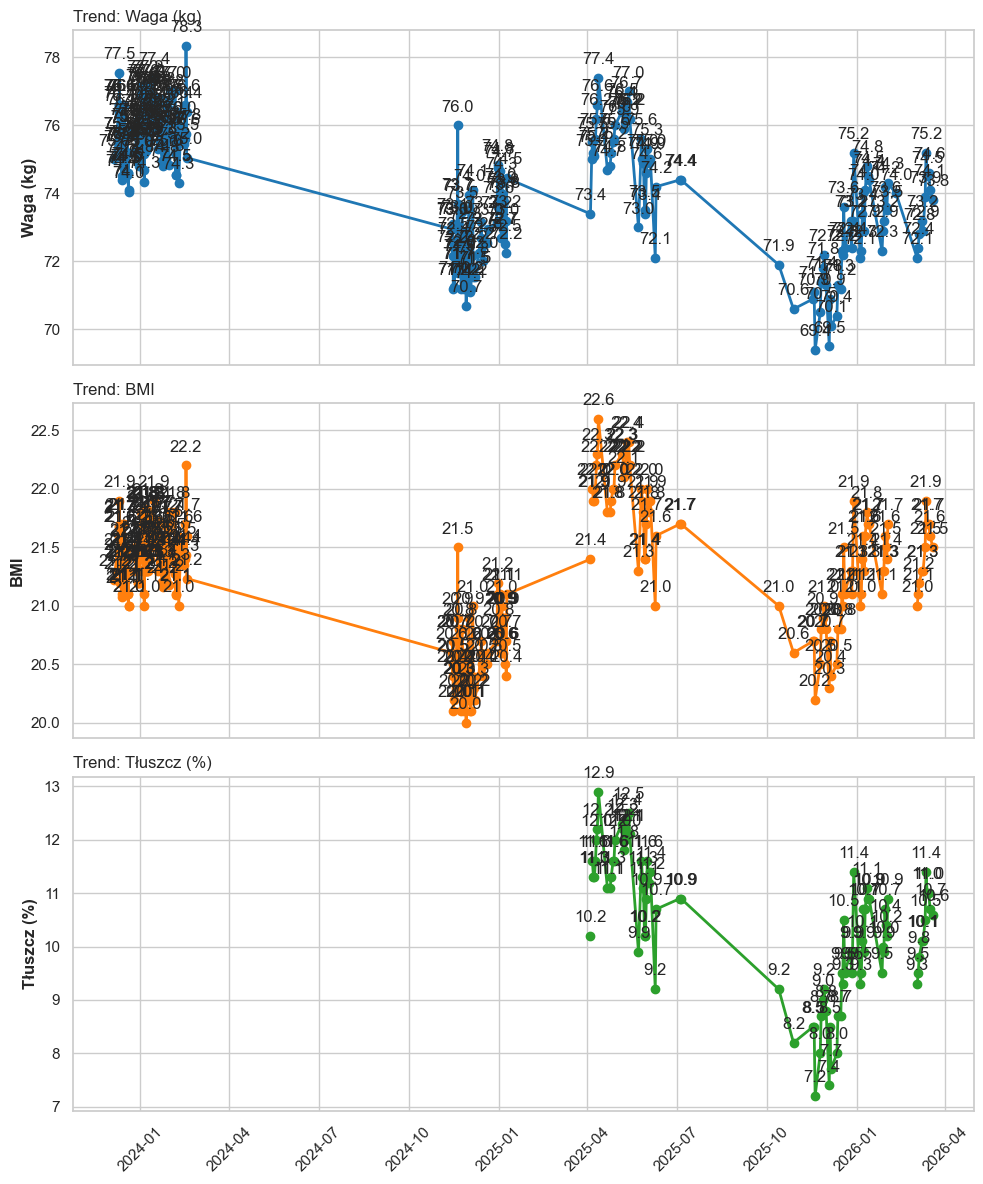

In [5]:
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import seaborn as sns

# 1. FUNKCJA PARSUJĄCA (ta sama co wcześniej)
def parse_apple_health_body_data(file_path):
    tree = ET.parse(file_path)
    root = tree.getroot()
    target_types = {
        'HKQuantityTypeIdentifierBodyMass': 'Weight_kg',
        'HKQuantityTypeIdentifierBodyMassIndex': 'BMI',
        'HKQuantityTypeIdentifierBodyFatPercentage': 'BodyFat_percent'
    }
    records = []
    for record in root.findall('Record'):
        record_type = record.get('type')
        if record_type in target_types:
            records.append({
                'Date': record.get('startDate'),
                'Metric': target_types[record_type],
                'Value': float(record.get('value'))
            })
    df = pd.DataFrame(records)
    df['Date'] = pd.to_datetime(df['Date'])
    pivot = df.pivot_table(index='Date', columns='Metric', values='Value').sort_index()
    if 'BodyFat_percent' in pivot.columns and pivot['BodyFat_percent'].max() < 1:
        pivot['BodyFat_percent'] *= 100
    return pivot

# 2. WYWOŁANIE I PRZYPISANIE (Tu był błąd - musimy stworzyć df_pivot)
# Podmień 'export.xml' na swoją nazwę pliku
df_pivot = parse_apple_health_body_data('data/apple_health_export/export.xml')

# 3. DODANIE NOWEGO WPISU
new_entry = pd.DataFrame({
    'BMI': [21.5],
    'BodyFat_percent': [10.6],
    'Weight_kg': [73.8]
}, index=[pd.to_datetime('2026-03-19 09:00:00+01:00')])

data = pd.concat([df_pivot, new_entry]).sort_index()

# 4. GENEROWANIE WYKRESÓW
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

metrics = ['Weight_kg', 'BMI', 'BodyFat_percent']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
labels = ['Waga (kg)', 'BMI', 'Tłuszcz (%)']

for i, metric in enumerate(metrics):
    if metric in data.columns:
        axes[i].plot(data.index, data[metric], marker='o', color=colors[i], linewidth=2)
        axes[i].set_ylabel(labels[i], fontweight='bold')
        axes[i].set_title(f'Trend: {labels[i]}', loc='left')
        for x, y in zip(data.index, data[metric]):
            if pd.notnull(y):
                axes[i].annotate(f'{y:.1f}', (x, y), textcoords="offset points", xytext=(0,10), ha='center')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()